In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Path to dataset files: /kaggle/input/imdb-dataset-of-50k-movie-reviews


In [2]:
import pandas as pd
df = pd.read_csv(path + "/IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
import numpy as np
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
# from sklearn.metrics import metrics

In [6]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [7]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [8]:
print(df.shape)

(50000, 2)


In [10]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
  text = text.lower()
  tokens = word_tokenize(text)
  tokens = [word for word in tokens if word.isalpha()]
  tokens = [word for word in tokens if word not in stop_words]
  tokens = [lemmatizer.lemmatize(word) for word in tokens]
  return ' '.join(tokens)

df['clean_text'] = df['review'].apply(preprocess)
df.head()

,review,sentiment,clean_text
0,One of the other reviewers has mentioned that ...,positive,one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei love time money visually stunnin...


In [11]:
vectorizer = TfidfVectorizer(max_features = 5000)

X = vectorizer.fit_transform(df['clean_text'])
y = df['sentiment']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [13]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [14]:
y_pred = model.predict(X_test)

In [15]:
print(f"Accuracy {accuracy_score(y_test, y_pred)*100}%")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy 85.09%
Classification Report:
              precision    recall  f1-score   support

    negative       0.85      0.84      0.85      4961
    positive       0.85      0.86      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



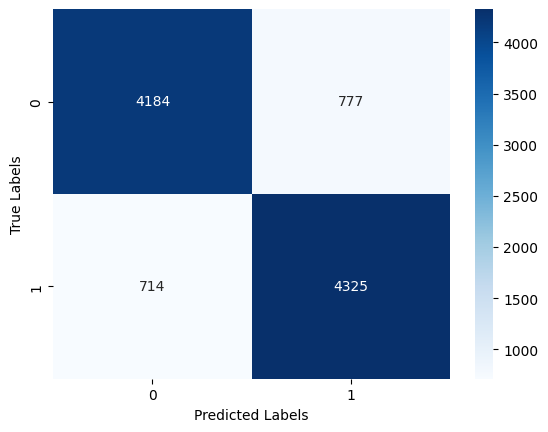

In [16]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt = 'd', cmap = 'Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [17]:
text = ['This movie was not good']
clean = preprocess(text[0])
vector = vectorizer.transform([clean])
prediction = model.predict(vector)
print("Predicted Sentiment:", prediction[0])

Predicted Sentiment: negative


In [18]:
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

In [19]:
vectorizer = TfidfVectorizer(max_features = 5000)

X = vectorizer.fit_transform(df['clean_text'])
y = df['sentiment']

In [20]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter = 200),
    "Random Forest": RandomForestClassifier(),
    "SVM": LinearSVC(),
    "Gradient Boosting": GradientBoostingClassifier()
}

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [22]:
result = []
for name, model in models.items():
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  result.append([name, accuracy, precision, recall, f1])

In [24]:
for re in result:
  print(f"{re[0]} Accuracy: {re[1]*100}%")
  print(f"{re[0]} Precision: {re[2]*100}%")
  print(f"{re[0]} Recall: {re[3]*100}%")
  print(f"{re[0]} F1 Score: {re[4]*100}%")
  print()

Naive Bayes Accuracy: 85.09%
Naive Bayes Precision: 84.77067816542532%
Naive Bayes Recall: 85.83052192895416%
Naive Bayes F1 Score: 85.29730795779508%

Logistic Regression Accuracy: 88.62%
Logistic Regression Precision: 87.76379477250727%
Logistic Regression Recall: 89.95832506449692%
Logistic Regression F1 Score: 88.84751078008624%

Random Forest Accuracy: 84.7%
Random Forest Precision: 85.53777597731415%
Random Forest Recall: 83.80631077594761%
Random Forest F1 Score: 84.66319165998397%

SVM Accuracy: 88.0%
SVM Precision: 87.40986162541415%
SVM Recall: 89.00575511014091%
SVM F1 Score: 88.20058997050147%

Gradient Boosting Accuracy: 81.3%
Gradient Boosting Precision: 78.66835534648091%
Gradient Boosting Recall: 86.28696169874975%
Gradient Boosting F1 Score: 82.3017225061518%



In [25]:
import pickle

# Best model
best_model = LogisticRegression(max_iter=200)
best_model.fit(X_train, y_train)

# Saving best model
pickle.dump(best_model, open('best_model.pkl', 'wb'))

# Save vectorizer
pickle.dump(vectorizer, open('vectorizer.pkl', 'wb'))

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!
